# Policy Optimization
This notebook demonstrates how metaheuristic search can be used to optimize the holding policy in effect along a fixed-line transit route.

In [3]:
from collections import defaultdict
from copy import deepcopy
from dataclasses import dataclass
from math import exp, log, sqrt
from os import path
from random import choice, random, seed

from pandas import read_csv
from plotly import graph_objects
from plotly import express
from scipy.special import erfinv

from analysis.policies import *
from analysis.routes import *
from analysis.prob_analysis import *
from analysis.wc_analysis import *
from optimizers.ant_colony import *
from optimizers.bayesian import *

import numpy
import pygad
import pyswarms

## Plotting Helpers

In [4]:
@dataclass
class GtfsStopConfig(StopConfig):
    """Configuration information required to construct a ```Stop``` with additional information appearing in a GTFS.

    :param stop_id: The stop_id as per the GTFS.
    :param scheduled_departures: The scheduled departure times as per the GTFS.
    """ 
    stop_id: str

In [5]:
@dataclass
class RouteConfig(object):
    """Configuration information that defines a route variant under test.
    
    :param name: Name used for identification.
    :param route: List of stops.
    :param start_times: List of times when vehicles start serving the route.
    """ 
    name: str
    route: list[Stop]
    start_times: list[float]

In [6]:
@dataclass
class HeadwayResults(object):
    """Headway experiment results.
    
    :param upper_bound: List of maximum possible headway at each stop.
    :param lower_bound: List of minimum possible headway at each stop.
    """ 
    upper_bound: list[float]
    lower_bound: list[float]

In [7]:
@dataclass
class RouteResults(object):
    """Results from an experiment on one route variant.
    
    :param name: Name used for identification.
    :param route: The route under consideration.
    :param headway: Simulated and analytical headway results for the route.
    """ 
    name: str
    route: list[Stop]
    headway: HeadwayResults

In [8]:
def plot_headway(exp_id: str, results: list[RouteResults], ctrl_pts: dict[str, str]) -> None:
    """Plot simulated and analytical headway bounds.

    :param exp_id: Experiment name used used when saving the figure.
    :param results: List of results for each route under consideration.
    :param ctrl_pts: Dictionary mapping control point stop IDs to human readable names.
    """
    fig = graph_objects.Figure()

    for idx, result in enumerate(results):
        fig.add_trace(graph_objects.Scatter(
            line_color=express.colors.qualitative.T10[idx],
            mode='lines',
            showlegend=False,
            x=[s for s in range(len(result.route))],
            y=result.headway.upper_bound,
        ))
        fig.add_trace(graph_objects.Scatter(
            fill='tonexty',
            line_color=express.colors.qualitative.T10[idx],
            mode='lines',
            name='$' + result.name + '$',
            showlegend=True,
            x=[s for s in range(len(result.route))],
            y=result.headway.lower_bound,
        ))

    xticks = ['' for j in range(len(results[0].route))]
    for idx, stop in enumerate(routes[0].route):
        if stop.stop_id in ctrl_pts:
            xticks[idx] = ctrl_pts[stop.stop_id]
            fig.add_vline(
                x=idx,
                line_width=2,
                line_dash="dash",
                line_color="black",
            )

    fig.update_layout(
        # General style
        font_family="Times New Roman, serif",
        
        # Dimensions
        height=360,
        width=850,
        
        # Axes
        xaxis=dict(
            tickangle=45,
            tickmode='array',
            ticktext=xticks,
            tickvals=[i for i in range(len(xticks))],
        ),
        yaxis=dict(
            title='Headway Bounds (min.)',
            title_standoff=0,
        ),

        # Legend
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=1.15,
            yanchor='top',
        ),
    )

    fig.show()
    fig.write_image(path.join('figures', f'{exp_id}.pdf'))

In [9]:
def run_experiment(exp_id: str, routes: list[RouteConfig], t_max: float, ctrl_pts: dict[str, str]) -> None:
    """Run an experiment.

    :param exp_id: Experiment name.
    :param routes: The routes (including start times) to compare.
    :param t_max: The cutoff time for simulation and analytical analysis.
    :param ctrl_pts: Dictionary mapping control point stop IDs to human readable names.
    """
    results = []
    for route in routes:
        print(f'Working on {route.name}...')
        headway_ub, headway_lb = headway_bounds(route_factory(route.route), route.start_times, t_max)
        results.append(RouteResults(
            name=route.name,
            route=route.route,
            headway=HeadwayResults(upper_bound=headway_ub, lower_bound=headway_lb),
        ))

    plot_headway(exp_id, results, ctrl_pts)

## Load a Route from a GTFS
Methods to create a route based on a GTFS and historic data.

In [10]:
def get_quantile_log_normal(mu: float, sigma: float, q: float) -> float:
    """Get a quantile's upper boundary (x | p(X < x) = q) for a log-normal distribution parameterized by mu and sigma.

    :param mu: The distribution's logarithm of location.
    :param sigma: The distribution's logarithm of scale.
    :return: The quantile's upper bound.
    """
    return exp(mu + sqrt(2 * sigma ** 2) * erfinv(2 * q - 1))

In [11]:
def get_log_normal_mixture(mu: list[float], sigma: list[float], weights: list[float] | None = None) -> tuple[float]:
    """Get the parameters of a log normal mixture approximated by log normal distribution.
    
    :param mu: List of logarithms of location for every log-normal distribution in the mixture.
    :param sigma: List of logarithms of scale for every log-normal distribution in the mixture.
    :param weight: List of weights for each log-normal distribution in the mixture.
    """
    assert len(mu) == len(sigma)
    if weights is None:
        w = [1 / len(mu) for _ in range(len(mu))]
    else:
        assert len(weights) == len(mu)
        w = weights

    # Calculate moments
    m1 = 0
    m2 = 0
    for i in range(len(mu)):
        m1 += w[i] * exp(mu[i] + (sigma[i] ** 2) / 2)
        m2 += (w[i] ** 2) * exp(2 * mu[i] + 2 * sigma[i] ** 2)
    temp = 0
    for i in range(len(sigma)):
        for j in range(i+1,len(sigma)):
            temp += (w[i] * w[j]) * exp(mu[i] + mu[j] + 0.5 * (sigma[i] ** 2 + sigma[j] ** 2))
    m2 = m2 + 2 * temp

    # Calculate new parameters
    sigma = sqrt(log(m2/(m1 ** 2)))
    mu = log(m1) - (sigma ** 2) / 2
    return mu, sigma

In [12]:
def load_route_from_gtfs(route_id: int, service_day: str) -> list[GtfsStopConfig]:
    """Create a route template from a GTFS.

    .. note ::
        This function does not load the stop schedules from the GTFS.  The assumption is that scheduled headway and number of vehicles
        are variables in the fixed-line route optimization problem.

    :param route_id: The route id in the GTFS.
    :param service_day: The service day in the GTFS the route template will be based on.
    :returns: List of stop configurations in order of service.
    :raises ValueError:
    """
    calendar = read_csv(path.join('gtfs', 'calendar.txt'))
    trips = read_csv(path.join('gtfs', 'trips.txt'))
    stops = read_csv(path.join('gtfs', 'stops.txt'))
    stop_times = read_csv(path.join('gtfs', 'stop_times.txt'))

    # Get service_id for selected day
    active_service_ids = calendar[calendar[service_day] == 1].service_id
    if len(active_service_ids) == 0:
        raise ValueError(f'No service on {service_day} in GTFS!')
    elif len(active_service_ids) > 1:
        raise ValueError(f'Multiple services on {service_day} in GTFS: multiple services are currently not supported!')
    service_id = active_service_ids.iloc[0]

    # Get the trips we care about
    trips = trips[(trips.service_id == service_id) & (trips.route_id == route_id)]

    # Map patterns (unique sequences of stops) to trips
    patterns_by_direction_id = defaultdict(set)
    trips_by_pattern = defaultdict(set)
    for block_id in [int(b) for b in trips.block_id.unique()]:
        for trip_id in [int(t) for t in trips[trips.block_id == block_id].trip_id.unique()]:
            pattern = tuple(stop_times[stop_times.trip_id == trip_id].sort_values(by='stop_sequence').stop_id)
            patterns_by_direction_id[trips[trips.trip_id == trip_id].direction_id.iloc[0].item()].add(pattern)
            trips_by_pattern[pattern].add(trip_id)

    # Select the most common pattern for each direction ID (we're ignoring weird, one-off patterns)
    selected_pattern_by_direction_id = {}
    for direction_id, patterns in patterns_by_direction_id.items():
        selected_pattern = max(patterns, key=lambda pattern: len(trips_by_pattern[pattern]))
        selected_pattern_by_direction_id[direction_id] = selected_pattern

    # Map stop_id and direction_id to Stop objects
    # Note: we assume direction_id=1, is the starting leg of the route
    stop_info = []
    for direction_id in list(selected_pattern_by_direction_id.keys())[::-1]:
        # Last stop in pattern is duplicated, since it is the first stop in the next direction
        for stop_id in selected_pattern_by_direction_id[direction_id][:-1]:
            stop_info.append(GtfsStopConfig(
                tau=None,
                delta=None,
                policy=BolehPolicy,
                policy_args={},
                stop_id=stop_id,
            ))

    return stop_info

In [13]:
def load_times(route: list[GtfsStopConfig], service_day: str, lower_quantile: float, upper_quantile: float) -> list[GtfsStopConfig]:
    """Load the travel and dwell times for a route defined in the GTFS.

    .. warning ::
        This function modifies the route argument in addition to returning a route.
    
    :param route: List of stop configuration in order of stops.
    :param service_day: The day of the weak whose data will be used to calculate the parameters.
    :param lower_quantile: The lower quantile of observed travel and dwell times to consider.
    :param upper_quantile: The uppler quantile of observed travel and dwell times to consider.
    :return: The route with updated travel and dwell time bounds.
    """
    travel_times = read_csv(path.join('data', 'travel_times.csv'))
    alight_rates = read_csv(path.join('data', 'alight_rates.csv'))
    demand_rates = read_csv(path.join('data', 'demand_rates_monday.csv'))

    for stop in route:
        tt = travel_times[(travel_times.day_of_week == service_day) & (travel_times.from_stop_id == stop.stop_id)]
        tt_mu = list(tt.mean_log_travel_time_s)
        tt_sigma = list(tt.std_log_travel_time_s)
        mu, sigma = get_log_normal_mixture(tt_mu, tt_sigma)
        lower = get_quantile_log_normal(mu, sigma, lower_quantile) / 60
        upper = get_quantile_log_normal(mu, sigma, upper_quantile) / 60
        stop.tau = (lower, upper)

        ar = alight_rates[alight_rates.STOP_ID == stop.stop_id]
        ar = list(ar.ALIGHT_RATE)
        dr = demand_rates[demand_rates.STOP_ID == stop.stop_id]
        dr = list(dr.HOURLY_DEMAND)

        weights = []
        for a, d in zip(ar, dr):
            weights.extend([10 / len(ar), 2 * a / len(ar), 3.5 * d / len(dr)])
        mu, sigma = get_log_normal_mixture([0 for _ in range(len(weights))], [0.1 for _ in range(len(weights))], weights)
        lower = get_quantile_log_normal(mu, sigma, lower_quantile) / 60
        upper = get_quantile_log_normal(mu, sigma, upper_quantile) / 60
        stop.delta = (lower, upper)

    return route

In [29]:
BASE_ROUTE = load_route_from_gtfs(route_id=55, service_day='monday')
BASE_ROUTE = load_times(BASE_ROUTE, service_day='Monday', lower_quantile=0.05, upper_quantile=0.95)

# The following are the only stops allowed to be considered for control during headway optimization:
CTRL_PTS = ['HICHICNN', 'MXIBELL', 'MXIGLENG', 'MXITHOMP', 'MXOTHOMP', 'MCC4_15']

# The following are additional route parameters that form a set of optimization constraints:
MAX_BUSES = 50
MAX_HOLD = 60

MIN_TRAVEL = sum([min(*s.tau) + min(*s.delta) for s in BASE_ROUTE])
MAX_TRAVEL = sum([max(*s.tau) + max(*s.delta) for s in BASE_ROUTE]) + MAX_HOLD
MIN_CTRL = [0 for _ in CTRL_PTS]
MAX_CTRL = [0 for _ in CTRL_PTS]
finished = [False for _ in CTRL_PTS]
for s in BASE_ROUTE:
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if not finished[idx]:
            MIN_CTRL[idx] += (min(*s.tau) + min(*s.delta))
            MAX_CTRL[idx] += (max(*s.tau) + max(*s.tau))
        if s.stop_id == ctrl_pt:
            finished[idx] = True
            MAX_CTRL[idx] += MAX_HOLD

## Genetic Algorithm

In [30]:
gene_space = [
    #{"low": 2.0, "high": MAX_BUSES},
    {"low": MAX_BUSES / MAX_TRAVEL, "high": MAX_BUSES / MIN_TRAVEL},
]
for ctrl_pt in CTRL_PTS:
    gene_space.extend([
        [0, 1, 2],
        {"low": 0.0, "high": 1.0},
        {"low": 0.0, "high": 1.0},
    ])

def fitness_function(ga: pygad.GA, solution: list, solution_idx: int) -> float:
    """This is the fitness function for the genetic algorithm.

    The solution parameter indices represent the following:
    0: Number of buses
    1: Initial headway between buses at start of route
    2, 5, 8, 11, ... : The policy for the (n-2)/3rd control point:
        0 - No holding
        1 - Schedule based control
        2 - Headway based control
    3, 6, 9, 12, ... : The first policy parameter for the (n-3)/3rd control point:
        0 - Nothing
        1 - Time delta
        2 - Activation ratio
    4, 7, 10, 13, ... : The second policy parameter for the (n-4)/3rd control point:
        0 - Nothing
        1 - Scheduling offset
        2 - Maximum holding time
    
    :param solution: List parameters for the soluton under test.
    :param solution_idx: Solution index from PyGAD.
    :return: The solution fitness. 
    """
    #start_times = [bus * solution[1] for bus in range(round(solution[0]))]
    mx_hold_time = 0
    solution = [None, *solution]
    start_times = [bus * solution[1] for bus in range(MAX_BUSES)]
    route = deepcopy(BASE_ROUTE)
    param_idx = 2
    for stop_idx in range(len(route)):
        for idx, ctrl_pt in enumerate(CTRL_PTS):
            if route[stop_idx].stop_id == ctrl_pt:
                policy = solution[param_idx]
                arg1 = solution[param_idx + 1]
                arg2 = solution[param_idx + 2]
                param_idx += 3
                if policy == 0:
                    pass
                elif policy == 1:
                    route[stop_idx].policy = InfiniteSchedulePolicy
                    route[stop_idx].policy_args = {
                        'time_delta': MAX_BUSES / MAX_TRAVEL * (1 - arg1) + arg1 * MAX_BUSES / MIN_TRAVEL,
                        'offset': MIN_CTRL[idx] * (1 - arg2) + arg2 * MAX_CTRL[idx],
                    }
                elif policy == 2:
                    route[stop_idx].policy = HeadwayDrivenPolicy
                    route[stop_idx].policy_args = {
                        'activation_ratio': arg1,
                        'max_holding': arg2 * MAX_HOLD,
                    }
                    mx_hold_time += arg2
    headway_ub, headway_lb = headway_bounds(route_factory(route), start_times, 24 * 60 * 365)
    fitness = -max(headway_ub)
    return [fitness, -mx_hold_time]

ga = pygad.GA(
    num_generations=18, # Remeber to increase
    num_parents_mating=9,
    fitness_func=fitness_function,
    sol_per_pop=18,
    num_genes=len(gene_space),
    gene_space=gene_space,
    #parent_selection_type='sss',
    parent_selection_type='nsga2',
    keep_parents=1,
    crossover_type='single_point',
    mutation_type='random',
    mutation_percent_genes=10
)

ga.run()
solution, solution_fitness, solution_idx = ga.best_solution()
print("Parameters of the best solution : {solution}".format(solution=solution))
print("Fitness value of the best solution = {solution_fitness}".format(solution_fitness=solution_fitness))

Parameters of the best solution : [4.68253400e-01 0.00000000e+00 1.29817672e-01 5.35888133e-01
 2.00000000e+00 1.18635268e-03 6.32058644e-01 0.00000000e+00
 9.00223443e-01 6.41737605e-01 0.00000000e+00 4.86217967e-01
 9.63205278e-01 1.00000000e+00 5.06430265e-02 8.49535232e-02
 0.00000000e+00 5.34433057e-01 1.02779427e-01]
Fitness value of the best solution = [-108.24277569   -0.63205864]


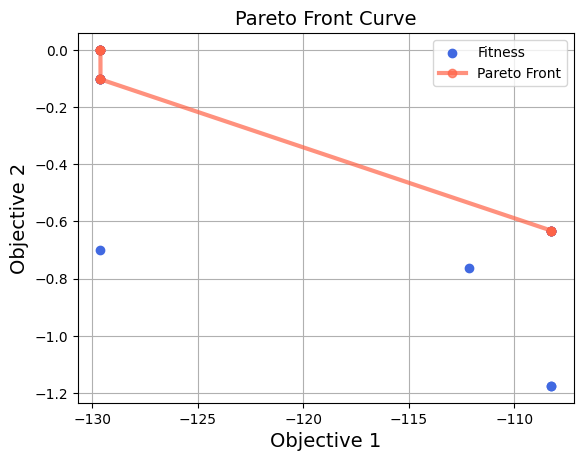

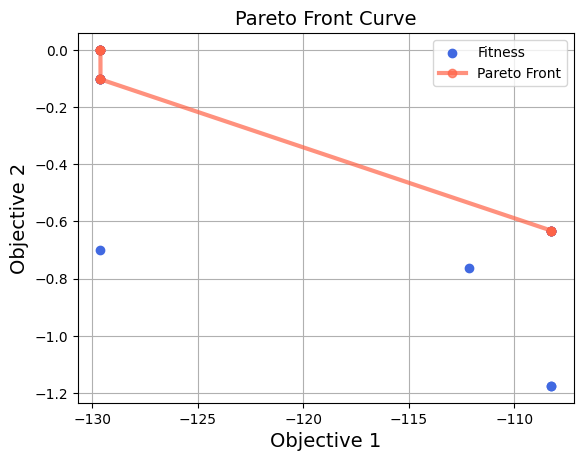

In [31]:
ga.plot_pareto_front_curve()

## Bayesian Optimization

In [23]:
gene_space = {
    "n_buses": (2, MAX_BUSES),
    "initial_headway": (MAX_BUSES / MAX_TRAVEL, MAX_BUSES / MIN_TRAVEL),
}
for ctrl_pt in CTRL_PTS:
    gene_space[f'{ctrl_pt}_policy'] = set({0, 1, 2})
    gene_space[f'{ctrl_pt}_arg1'] = (0.0, 1.0)
    gene_space[f'{ctrl_pt}_arg2'] = (0.0, 1.0)

def objective_function(**kwargs) -> float:
    """This is the objective function for Bayesian optimization.

    The parameter indices represent the following:
    0: Number of buses
    1: Initial headway between buses at start of route
    2, 5, 8, 11, ... : The policy for the (n-2)/3rd control point:
        0 - No holding
        1 - Schedule based control
        2 - Headway based control
    3, 6, 9, 12, ... : The first policy parameter for the (n-3)/3rd control point:
        0 - Nothing
        1 - Time delta
        2 - Activation ratio
    4, 7, 10, 13, ... : The second policy parameter for the (n-4)/3rd control point:
        0 - Nothing
        1 - Scheduling offset
        2 - Maximum holding time
    
    :param parameters: List parameters for the soluton under test.
    :return: The objective function evaluated with <parameters>. 
    """
    start_times = [bus * kwargs["initial_headway"] for bus in range(round(kwargs["n_buses"]))]
    route = deepcopy(BASE_ROUTE)
    param_idx = 2
    for stop_idx in range(len(route)):
        for idx, ctrl_pt in enumerate(CTRL_PTS):
            if route[stop_idx].stop_id == ctrl_pt:
                policy = kwargs[f'{ctrl_pt}_policy']
                arg1 = kwargs[f'{ctrl_pt}_arg1']
                arg2 = kwargs[f'{ctrl_pt}_arg2']
                param_idx += 3
                if policy == 0:
                    pass
                elif policy == 1:
                    route[stop_idx].policy = InfiniteSchedulePolicy
                    route[stop_idx].policy_args = {
                        'time_delta': MAX_BUSES / MAX_TRAVEL * (1 - arg1) + arg1 * MAX_BUSES / MIN_TRAVEL,
                        'offset': MIN_CTRL[idx] * (1 - arg2) + arg2 * MAX_CTRL[idx],
                    }
                elif policy == 2:
                    route[stop_idx].policy = HeadwayDrivenPolicy
                    route[stop_idx].policy_args = {
                        'activation_ratio': arg1,
                        'max_holding': arg2 * MAX_HOLD,
                    }
    print(kwargs["n_buses"], kwargs["initial_headway"])
    headway_ub, headway_lb = headway_bounds(route_factory(route), start_times, 24 * 60 * 365)
    fitness = -max(headway_ub)
    return fitness

bo = BayesianOptimizer(
    objective_f=objective_function,
    constraint_f=None,
    constraints=None,
    variables=gene_space,
    n_init=5,
    n_iter=50,
    early_stopping=0,
    acquisition_f='ei',
)

parameters, objective = bo.optimize()
print(objective)
print(parameters)

4.604744895762947 0.12310496901622969
11.635389940891436 0.13292841753118906
8.672084300708768 0.12313728986935317
13.716167584821648 0.11747334563703782
3.0034062248293347 0.16523474937176696
[12.18547747  0.66420722  1.46492328  1.7717412   1.74920258  1.0006155
  0.67780014  0.62068029  1.87534911  1.0323824   0.45616419  1.36399496
  1.1118353   0.8945977 ]
299
[9.33802954 0.47200985 1.1826933  0.98454273 0.55279693 1.72024957
 1.29094964 0.92024098 0.52128493 0.70862791 0.61389929 0.91613203
 0.98005622 1.1908358 ]
360
[5.57490084 1.00265879 1.00278175 1.7292769  1.74218926 0.50427878
 1.54625917 1.51344563 0.98180823 0.79785417 1.63433208 0.26951103
 0.51119536 1.0769899 ]
486
[3.69388586 0.21564742 1.00386092 0.30750124 0.40253767 1.30191037
 0.35196631 1.09777982 0.80057568 1.91459518 0.87665858 0.45422275
 1.41494479 1.4133671 ]
614
[14.70546497  0.65119887  1.0249043   1.11838606  1.10304712  1.26142177
  1.60335781  1.23946579  1.27572245  1.13579211  1.13630811  1.41023746


## Nested Metaheuristic Optimization

In [15]:
import numpy

class AntColonyOptimizer(object):
    """
    Ant colony optimizer.

    graph = transition matrix
    goal = index of goal nodes
    f_obj = objective function to evaluate on ant's subgraph
    n_ants - number of ants
    alpha = pheromone influence parameter
    beta = distance influence parameter
    rho = pheromone decay parameter
    tau_max = maximum pheromone an ant can lay down
    """

    def __init__(self, graph, goal, f_obj, n_ants, alpha, beta, rho, tau_max):
        self.graph = graph
        self.goal = goal
        self.f_obj = f_obj
        self.n_ants = n_ants
        self.alpha = alpha
        self.beta = beta
        self.rho = rho
        self.tau_max = tau_max
        self.tau = self.graph.copy()
        self.best = None
        self.converged = False
        self.iters = 0

    def tick(self):
        # Edge Selection
        pxy = self.tau ** self.alpha * self.graph ** self.beta
        print(pxy)
        ants = []
        for ant in range(self.n_ants):
            visited = []
            node = 0
            while node not in self.goal:
                node = numpy.random.choice(
                    list(range(pxy[node, :].size)),
                    p=pxy[node, :] / numpy.sum(pxy[node, :])
                ).item()
                visited.append(node)
            ants.append(visited)

        # Check for convergence (all ants on same path)
        self.converged = True
        for idx in range(1, len(ants)):
            if ants[idx - 1] != ants[idx]:
                self.converged = False
                break

        # Evaluate Subgraphs
        print(f"### ITER {self.iters} ###")
        rewards = []
        for ant in ants:
            r, args = self.f_obj(ant)
            r = -r
            if self.best is None or r > self.best[0]:
                self.best = (r, ant, args)
            print(f"Ant Reward: {r}")
            rewards.append(r)
        rewards = numpy.array(rewards)
        rewards = rewards - numpy.amin(rewards)
        rewards = rewards / numpy.amax(rewards)
        
        # Pheromone Update
        dtau = []
        for ant, reward in zip(ants, rewards):
            sg = numpy.zeros(pxy.shape)
            prev = 0
            for node in ant:
                sg[prev, node] = 1
                prev = node
            dtau.append(reward * sg)
        self.tau = (1 - self.rho) * pxy + sum(dtau)
        self.iters += 1
        return

    def optimize(self):
        while not self.converged:
            self.tick()
        return self.best

In [16]:
import pyswarms
import random

# USER CHOOSES
MAX_BUSES = 20
MAX_HOLD = 60

# ROUTE DETERMINED
MIN_TRAVEL = sum([min(*s.tau) + min(*s.delta) for s in BASE_ROUTE])
MAX_TRAVEL = sum([max(*s.tau) + max(*s.delta) for s in BASE_ROUTE]) + MAX_HOLD
MIN_CTRL = [0 for _ in CTRL_PTS]
MAX_CTRL = [0 for _ in CTRL_PTS]
finished = [False for _ in CTRL_PTS]
for s in BASE_ROUTE:
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if not finished[idx]:
            MIN_CTRL[idx] += (min(*s.tau) + min(*s.delta))
            MAX_CTRL[idx] += (max(*s.tau) + max(*s.tau))
        if s.stop_id == ctrl_pt:
            finished[idx] = True
            MAX_CTRL[idx] += MAX_HOLD


def inner_objective(policy_args, stop_policies=None):
    # construct the route
    reward = []
    for p in range(len(policy_args)):
        route = deepcopy(BASE_ROUTE)
        policy_args_idx = 2
        stop_policies_idx = 0
        for i in range(len(route)):
            for ctrl_pt in CTRL_PTS:
                if route[i].stop_id == ctrl_pt:
                    policy = (stop_policies[stop_policies_idx] - 1) % 3
                    if policy == 0:
                        pass
                    elif policy == 1:
                        route[i].policy = InfiniteSchedulePolicy
                        route[i].policy_args = {
                            'time_delta': policy_args[p, 1].item(),
                            'offset': policy_args[p, policy_args_idx + 1].item(),
                        }
                        policy_args_idx += 2
                    elif policy == 2:
                        route[i].policy = HeadwayDrivenPolicy
                        route[i].policy_args = {
                            'activation_ratio': policy_args[p, policy_args_idx].item(),
                            'max_holding': policy_args[p, policy_args_idx + 1].item() * MAX_HOLD,
                        }
                        policy_args_idx += 2
                    stop_policies_idx += 1

        start_times = [b * policy_args[p, 1].item() for b in range(max(2, round(policy_args[p, 0].item())))]
        headway_ub, headway_lb = headway_bounds(route_factory(route), start_times, 24 * 60 * 365)
        reward.append(numpy.amax(headway_ub)) # PySwarms minimizes by default
    return reward
        

def outer_objective(stop_policies):
    """Take a list of integers corresponding to policies at each stop. 0 = None, 1 = Schedule, 2 = Dynamic.
    Maximize inner objective and return the performance (bigger is better). """
    lb = [2] # cannot have less than two buses (1 bus => no holding)
    ub = [MAX_BUSES] # constraint on max buses
    lb.append(MAX_BUSES / MAX_TRAVEL) # release buses min offset
    ub.append(MAX_BUSES / MIN_TRAVEL) # release buses at max offset
    for idx, s in enumerate(stop_policies):
        if (s - 1) % 3 == 0:
            pass
        elif (s - 1) % 3 == 1:
            lb.append(MAX_BUSES / MIN_TRAVEL) # Minimum interdeparture time
            ub.append(MAX_BUSES / MAX_TRAVEL) # Maximum departure time
            lb.append(MIN_CTRL[idx]) # Schedule offset min
            ub.append(MAX_CTRL[idx]) # Schedule offset max
        elif (s - 1) % 3 == 2:
            lb.append(0) # Lowest activation ratio (same as uncontrolled)
            ub.append(1) # Activation ration > 1 doesn't make sense
            lb.append(0) # Max hold 0 min (same as uncontrolled)
            ub.append(1) # % of max hold
    lb = numpy.array(lb)
    ub = numpy.array(ub)
    assert lb.size == ub.size
    
    inner_optimizer = pyswarms.single.global_best.GlobalBestPSO(
        n_particles=lb.size,
        dimensions=lb.size,
        options=dict(c1=random.random(), c2=random.random(), w=random.random()),
        bounds=(lb, ub),
        #bh_strategy='nearest',
        ftol=1,
    )

    return inner_optimizer.optimize(inner_objective, iters=100, verbose=False, stop_policies=stop_policies)
    

In [17]:
# First build graph for the ants to optimize
N_POL = 3
graph = numpy.zeros(tuple([N_POL * len(CTRL_PTS) + 1] * 2))
for c in range(1, N_POL + 1):
    graph[0, c] = 1
for r in range(1, N_POL * (len(CTRL_PTS) - 1), N_POL):
    graph[r:r+N_POL, r+N_POL:r+2*N_POL] = numpy.ones((N_POL, N_POL))

optimizer = AntColonyOptimizer(
    graph=graph,
    goal=list(range(graph.shape[0] - N_POL, graph.shape[0])), 
    f_obj=outer_objective,
    n_ants=graph.shape[0],
    alpha=1,
    beta=1,
    rho=0.5,
    tau_max=1
)

In [18]:
import random
numpy.random.seed(0)
random.seed(0)

optimizer.optimize()

[[0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

(np.float64(-127.47830086480975),
 [3, 6, 9, 12, 13, 18],
 array([19.76102712,  0.19520481,  0.88338498,  0.43323193,  0.03372796,
         0.94388616,  0.85993537,  0.19446403,  0.95981153,  0.2851278 ,
         0.52419852,  0.31943506]))

In [51]:
BAD_ROUTES[0]

IndexError: list index out of range

In [43]:
@dataclass
class HeadwayResults(object):
    """Headway experiment results.
    
    :param upper_bound: List of maximum possible headway at each stop.
    :param lower_bound: List of minimum possible headway at each stop.
    :param observed: List of headway times observed during simulation at each stop.
    """ 
    upper_bound: list[float]
    lower_bound: list[float]
    observed: list[list[float]]

@dataclass
class RouteResults(object):
    """Results from an experiment on one route variant.
    
    :param name: Name used for identification.
    :param route: The route under consideration.
    :param headway: Simulated and analytical headway results for the route.
    :param travel_time: Measured travel times between all pairs of stops.
    """ 
    name: str
    route: list[Stop]
    headway: HeadwayResults
    travel_time: list[list[list[float]]]

def plot_headway(exp_id: str, results: list[RouteResults]) -> None:
    """Plot simulated and analytical headway bounds.

    :param exp_id: Experiment name used used when saving the figure.
    :param results: List of results for each route under consideration.
    """
    fig = graph_objects.Figure()
    whitespace = 0.2
    width = (1 - whitespace) / len(results)

    for i, result in enumerate(results):
        offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width

        for stop_idx in range(len(result.route)):
            fig.add_trace(graph_objects.Bar(
                base=[result.headway.lower_bound[stop_idx]],
                legend='legend1',
                marker={'color': express.colors.qualitative.T10[i]},
                marker_pattern_shape='x',
                name='$' + result.name + r'\textrm{ (Bounds)}' + '$',
                opacity=0.5,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset],
                y=[result.headway.upper_bound[stop_idx]],
            ))
            fig.add_trace(graph_objects.Box(
                legend='legend2',
                marker={'color': express.colors.qualitative.T10[i]},
                name='$' + result.name + r'\textrm{ (Sim.)}' + '$',
                opacity=1.0,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset] * len(result.headway.observed[stop_idx]),
                y=result.headway.observed[stop_idx],
            ))

    fig.update_layout(
        # General style
        font_family='Times New Roman, serif',
        plot_bgcolor='white',

        # Dimensions
        height=360,
        width=750,

        # Axes
        xaxis=dict(
            side='top',
            tickmode='array',
            tickvals=[j for j in range(max([len(r.route) for r in results]))],
            title='Stop #',
            title_standoff=0.0,
        ),
        yaxis=dict(
            gridcolor='lightgrey',
            showgrid=True,
            title='Headway Time (min.)',
            title_standoff=0.0,
            zeroline=True,
            zerolinecolor='lightgrey',
        ),

        # Legends
        legend1=dict(
            orientation='v',
            x=0.25,
            xanchor='center',
            y=-0.15 * len(results),
            yanchor='bottom',
        ),
        legend2=dict(
            orientation='v',
            x=0.75,
            xanchor='center',
            y=-0.15 * len(results),
            yanchor='bottom',
        ),
    )

    fig.show()
    fig.write_image(path.join('figures', f'{exp_id}.pdf'))

def run_experiment(exp_id: str, routes: list, start_times: list, t_max: float) -> None:
    """Run an experiment.

    :param exp_id: Experiment name.
    :param routes: The routes (including start times) to compare.
    :param t_max: The cutoff time for simulation and analytical analysis.
    """
    results = []
    for route, st in zip(routes, start_times):
        headway_ub, headway_lb = headway_bounds(route_factory(route), st, t_max)
        print(all([b == 0 for b in headway_ub]))
        pr_results = simulate(route_factory(route), st, t_max)
        results.append(RouteResults(
            name="Test",
            route=route,
            headway=HeadwayResults(upper_bound=headway_ub, lower_bound=headway_lb, observed=pr_results['headway']),
            travel_time=pr_results['travel'],
        ))

    plot_headway(exp_id, results)

2026-05-19 10:43:13,854 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-05-19 10:43:13,855 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.


2026-05-19 11:16:21,245 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-05-19 11:16:21,246 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.


False


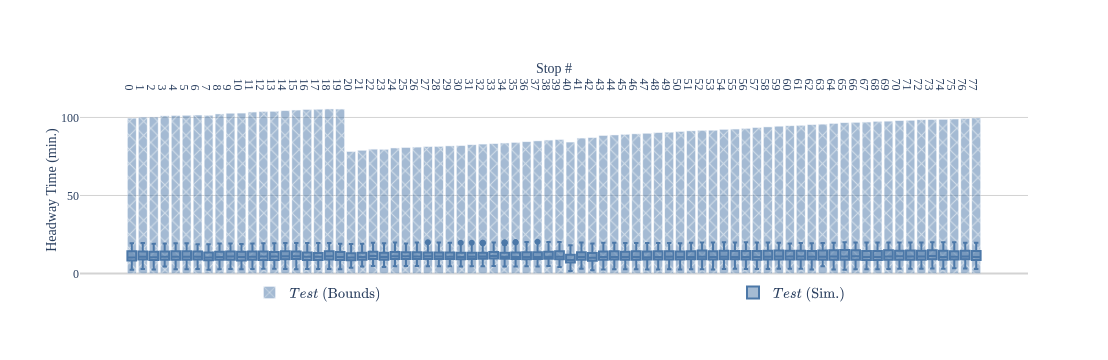

2026-05-19 11:19:21,261 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-05-19 11:19:21,261 - choreographer.browsers.chromium - INFO - Found chromium path: /home/yuhasm/.local/share/choreographer/deps/chrome-linux64/chrome
2026-05-19 11:19:21,262 - choreographer.utils._tmpfile - INFO - Temp directory created: /tmp/tmp_xopshn7.
2026-05-19 11:19:21,262 - choreographer.browser_async - INFO - Opening browser.
2026-05-19 11:19:21,263 - choreographer.utils._tmpfile - INFO - Temp directory created: /tmp/tmpj8yq1q88.
2026-05-19 11:19:21,263 - choreographer.browsers.chromium - INFO - Temporary directory at: /tmp/tmpj8yq1q88
2026-05-19 11:19:21,442 - kaleido.kaleido - INFO - Conforming 1 to file:///tmp/tmp_xopshn7/index.html
2026-05-19 11:19:21,443 - kaleido.kaleido - INFO - Waiting on all navigates
2026-05-19 11:19:22,289 - kaleido.kaleido - INFO - All navigates done, putting them all in queue.
2026-05-19 11:19:22,390 - kaleido.kaleido - INFO - Getting tab from qu

In [47]:
run_experiment("Test", routes=[BAD_ROUTES[-1]], start_times=[BAD_START_TIMES[-1][:10]], t_max=24 * 60)

In [46]:
BAD_START_TIMES[-1]

[0.0,
 11.064784821071504,
 22.129569642143007,
 33.19435446321451,
 44.259139284286015,
 55.32392410535752,
 66.38870892642902,
 77.45349374750053,
 88.51827856857203,
 99.58306338964353,
 110.64784821071504,
 121.71263303178654,
 132.77741785285804,
 143.84220267392953,
 154.90698749500106,
 165.97177231607256,
 177.03655713714406,
 188.10134195821556]